# Projet 3 — Détection de Fake News
## Partie 1 : Exploration et analyse du LIAR Dataset (EDA)

**Objectif de ce notebook :**
- Télécharger et charger le LIAR dataset
- Comprendre sa structure (colonnes, types, valeurs manquantes)
- Analyser la distribution des labels (déséquilibre de classes)
- Explorer les métadonnées : speaker, parti politique, sujet
- Choisir et justifier le dataset externe pour l'évaluation out-of-domain

---

## 0. Installation et imports

In [1]:
# ── Imports standard ──────────────────────────────────────────────────────────
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Nuage de mots (optionnel, utile pour visualiser les statements)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud non installé — section nuage de mots ignorée")

# ── Style global des graphiques ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

print("✓ Imports OK")

✓ Imports OK


---
## 2. Chargement et structure du dataset

Le fichier `.tsv` n'a **pas d'en-tête** : on doit nommer les colonnes manuellement.

| # | Nom | Description |
|---|-----|-------------|
| 0 | `id` | Identifiant unique de la déclaration |
| 1 | `label` | Véracité : 6 niveaux (pants-fire → true) |
| 2 | `statement` | Texte de la déclaration politique |
| 3 | `subject` | Thème(s) abordé(s) |
| 4 | `speaker` | Nom de la personne |
| 5 | `speaker_job` | Fonction du locuteur |
| 6 | `state_info` | État américain |
| 7 | `party_affiliation` | Parti politique |
| 8–12 | `*_counts` | Historique des labels du locuteur |
| 13 | `context` | Lieu/contexte de la déclaration |

In [2]:
# ── Noms des 14 colonnes (le fichier n'a pas d'en-tête) ───────────────────────
COLUMNS = [
    "id",                  # col 0  : identifiant unique
    "label",               # col 1  : label de véracité (TARGET)
    "statement",           # col 2  : texte de la déclaration (FEATURE principale)
    "subject",             # col 3  : thème(s) politique(s)
    "speaker",             # col 4  : nom du locuteur
    "speaker_job",         # col 5  : fonction / poste
    "state_info",          # col 6  : état américain
    "party_affiliation",   # col 7  : parti politique
    "barely_true_counts",  # col 8  : nb de fois étiqueté barely-true
    "false_counts",        # col 9  : nb de fois étiqueté false
    "half_true_counts",    # col 10 : nb de fois étiqueté half-true
    "mostly_true_counts",  # col 11 : nb de fois étiqueté mostly-true
    "pants_on_fire_counts",# col 12 : nb de fois étiqueté pants-on-fire
    "context"              # col 13 : lieu / format (débat, discours, tweet...)
]

# ── Chargement des 3 splits ───────────────────────────────────────────────────
train = pd.read_csv("data/train.tsv", sep="\t", header=None, names=COLUMNS)
valid = pd.read_csv("data/valid.tsv", sep="\t", header=None, names=COLUMNS)
test  = pd.read_csv("data/test.tsv",  sep="\t", header=None, names=COLUMNS)

# ── Ajout d'une colonne pour identifier le split d'origine ────────────────────
train["split"] = "train"
valid["split"] = "valid"
test["split"]  = "test"

# ── Dataset complet (utile pour certaines analyses globales) ──────────────────
df = pd.concat([train, valid, test], ignore_index=True)

print(f"Train  : {len(train):,} lignes")
print(f"Valid  : {len(valid):,} lignes")
print(f"Test   : {len(test):,} lignes")
print(f"Total  : {len(df):,} lignes")

Train  : 10,240 lignes
Valid  : 1,284 lignes
Test   : 1,267 lignes
Total  : 12,791 lignes


In [3]:
# ── Aperçu des 3 premières lignes ─────────────────────────────────────────────
# On affiche uniquement les colonnes clés pour la lisibilité
df[["label", "statement", "speaker", "party_affiliation", "subject"]].head(3)

,label,statement,speaker,party_affiliation,subject
0,false,Says the Annies List political group supports ...,dwayne-bohac,republican,abortion
1,half-true,When did the decline of coal start? It started...,scott-surovell,democrat,"energy,history,job-accomplishments"
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",barack-obama,democrat,foreign-policy


In [4]:
# ── Informations générales sur le dataset ────────────────────────────────────
print("=" * 50)
print("TYPES ET VALEURS MANQUANTES")
print("=" * 50)
print(df.dtypes)
print()
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()

# ── Nombre de valeurs uniques (utile pour les colonnes catégorielles) ─────────
print("Valeurs uniques par colonne :")
for col in ["label", "speaker", "party_affiliation", "subject", "context"]:
    print(f"  {col:25s}: {df[col].nunique()} valeurs uniques")

TYPES ET VALEURS MANQUANTES
id                       object
label                    object
statement                object
subject                  object
speaker                  object
speaker_job              object
state_info               object
party_affiliation        object
barely_true_counts      float64
false_counts            float64
half_true_counts        float64
mostly_true_counts      float64
pants_on_fire_counts    float64
context                  object
split                    object
dtype: object

Valeurs manquantes par colonne :
id                         0
label                      0
statement                  0
subject                    2
speaker                    2
speaker_job             3568
state_info              2751
party_affiliation          2
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
context                  131
split                      0
dtype: in

In [5]:
# ── Exemple de déclarations par label ─────────────────────────────────────────
# Comprendre concrètement ce que chaque label représente

print("EXEMPLES DE DÉCLARATIONS PAR LABEL")
print("=" * 70)

label_order = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

for label in label_order:
    exemple = df[df["label"] == label]["statement"].iloc[0]
    # Tronquer à 100 caractères pour la lisibilité
    print(f"\n[{label.upper()}]")
    print(f"  {exemple[:120]}..." if len(exemple) > 120 else f"  {exemple}")

EXEMPLES DE DÉCLARATIONS PAR LABEL

[PANTS-FIRE]
  In the case of a catastrophic event, the Atlanta-area offices of the Centers for Disease Control and Prevention will sel...

[FALSE]
  Says the Annies List political group supports third-trimester abortions on demand.

[BARELY-TRUE]
  Jim Dunnam has not lived in the district he represents for years now.

[HALF-TRUE]
  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) ...

[MOSTLY-TRUE]
  Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."

[TRUE]
  The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of tenured (UW) faculty...


---
## 3. Distribution des labels — déséquilibre de classes

C'est l'une des premières choses à analyser : si les classes sont déséquilibrées,
un modèle naïf peut obtenir une bonne accuracy en prédisant toujours la classe majoritaire.
Il faudra prendre des mesures (class_weight, oversampling, regroupement).

In [6]:
# ── Comptage et pourcentages des labels ───────────────────────────────────────
label_order = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

label_counts = train["label"].value_counts().reindex(label_order)
label_pct    = (label_counts / len(train) * 100).round(1)

print("Distribution des labels dans le TRAIN set :")
print("-" * 45)
for lbl in label_order:
    bar = "█" * int(label_pct[lbl] / 2)  # barre ASCII proportionnelle
    print(f"  {lbl:15s} : {label_counts[lbl]:5d} ({label_pct[lbl]:5.1f}%)  {bar}")
print("-" * 45)
print(f"  {'TOTAL':15s} : {len(train):5d}")

Distribution des labels dans le TRAIN set :
---------------------------------------------
  pants-fire      :   839 (  8.2%)  ████
  false           :  1995 ( 19.5%)  █████████
  barely-true     :  1654 ( 16.2%)  ████████
  half-true       :  2114 ( 20.6%)  ██████████
  mostly-true     :  1962 ( 19.2%)  █████████
  true            :  1676 ( 16.4%)  ████████
---------------------------------------------
  TOTAL           : 10240


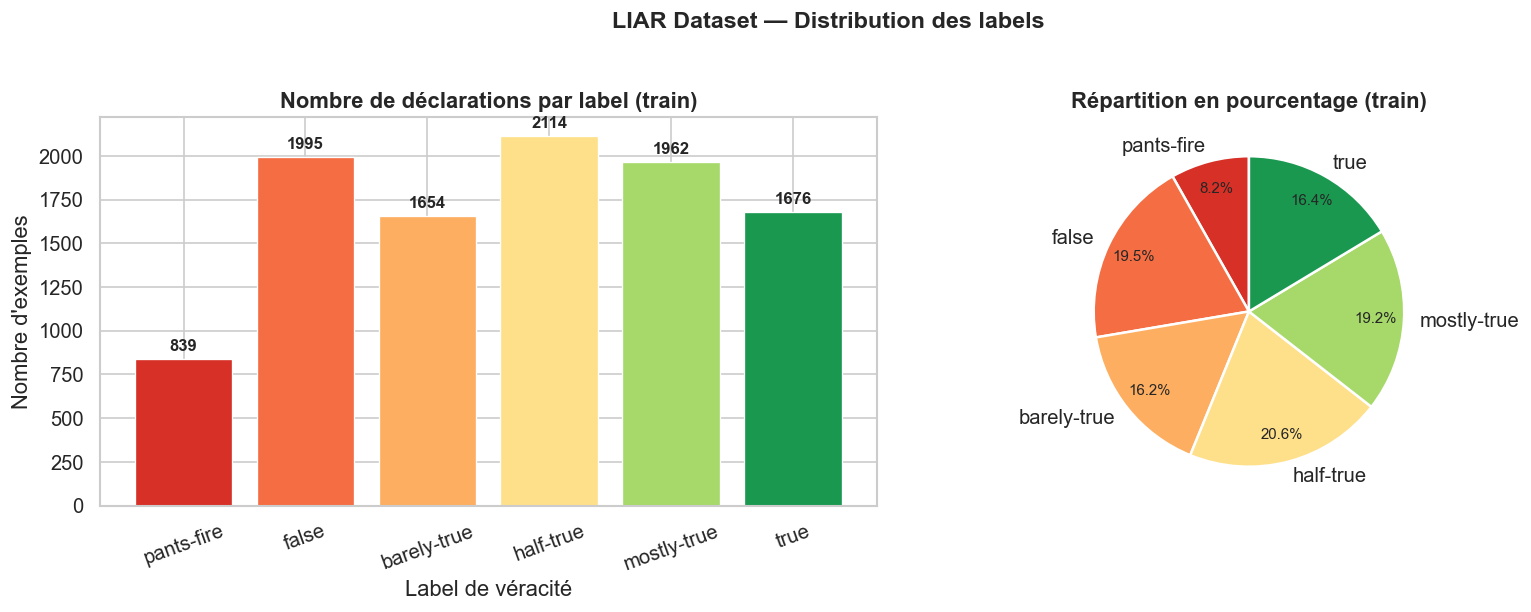


→ OBSERVATION : Les classes sont relativement équilibrées (~14-19% chacune)
  mais 'pants-fire' est sous-représenté (~8.5%).
  Pour une classification binaire, regrouper en FAKE (pants-fire+false+barely-true)
  vs REAL (half-true+mostly-true+true) donne deux classes quasi-équilibrées.


In [7]:
# ── Visualisation 1 : Distribution des 6 labels (barplot) ────────────────────

# Palette de couleurs : du rouge (mensonge) au vert (vrai)
colors = ["#d73027", "#f46d43", "#fdae61", "#fee08b", "#a6d96a", "#1a9850"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique gauche : counts absolus ---
axes[0].bar(label_order, label_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title("Nombre de déclarations par label (train)", fontweight='bold')
axes[0].set_xlabel("Label de véracité")
axes[0].set_ylabel("Nombre d'exemples")
axes[0].tick_params(axis='x', rotation=20)
# Afficher la valeur au-dessus de chaque barre
for i, (lbl, val) in enumerate(zip(label_order, label_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Graphique droite : pourcentages (camembert) ---
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=label_order,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
axes[1].set_title("Répartition en pourcentage (train)", fontweight='bold')

plt.suptitle("LIAR Dataset — Distribution des labels", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_01_label_distribution.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ OBSERVATION : Les classes sont relativement équilibrées (~14-19% chacune)")
print("  mais 'pants-fire' est sous-représenté (~8.5%).")
print("  Pour une classification binaire, regrouper en FAKE (pants-fire+false+barely-true)")
print("  vs REAL (half-true+mostly-true+true) donne deux classes quasi-équilibrées.")

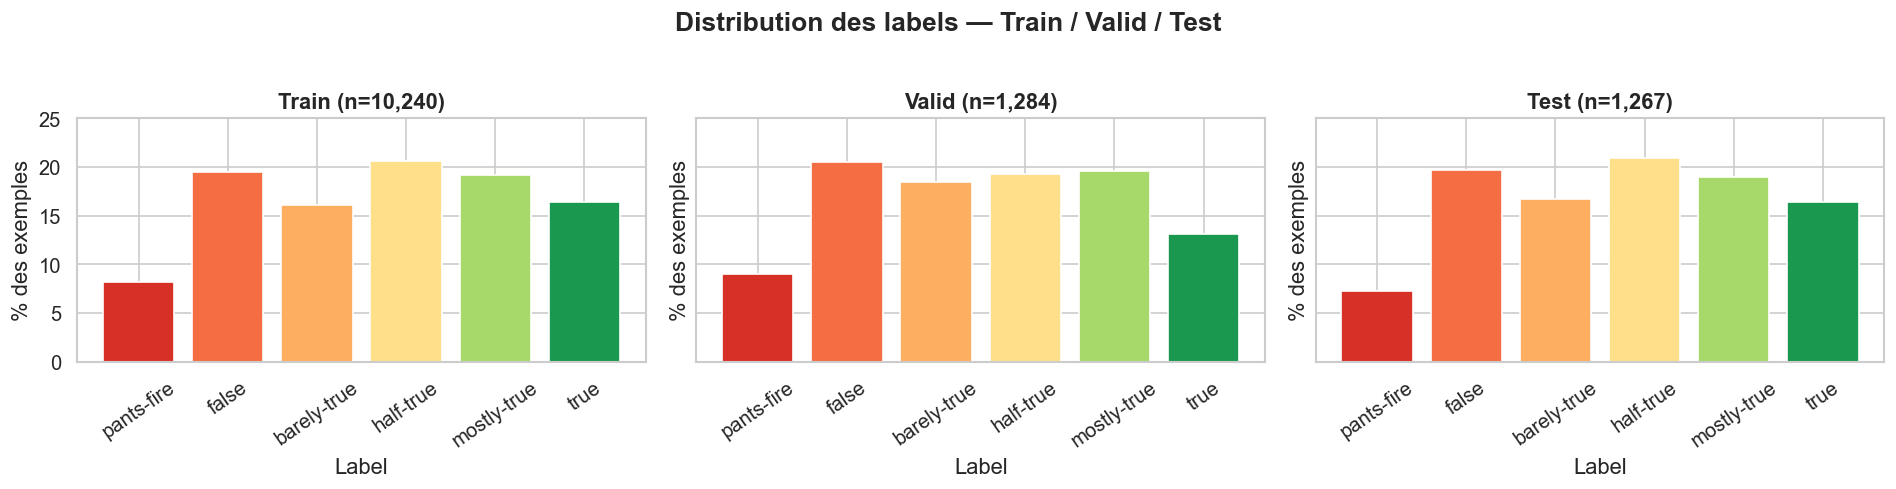

→ OBSERVATION : La répartition est stable entre les 3 splits — bon signe,
  le dataset a été stratifié lors du split.


In [8]:
# ── Visualisation 2 : Distribution comparée train / valid / test ──────────────
# Vérifier que la répartition est cohérente entre les 3 splits

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, split_df) in zip(axes, [("Train", train), ("Valid", valid), ("Test", test)]):
    counts = split_df["label"].value_counts().reindex(label_order)
    pct    = counts / len(split_df) * 100
    ax.bar(label_order, pct.values, color=colors, edgecolor='white')
    ax.set_title(f"{name} (n={len(split_df):,})", fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("% des exemples")
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylim(0, 25)

plt.suptitle("Distribution des labels — Train / Valid / Test", fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_02_split_distribution.png", bbox_inches='tight', dpi=150)
plt.show()

print("→ OBSERVATION : La répartition est stable entre les 3 splits — bon signe,")
print("  le dataset a été stratifié lors du split.")

Distribution binaire (train) :
  REAL :  5752 (56.2%)
  FAKE :  4488 (43.8%)


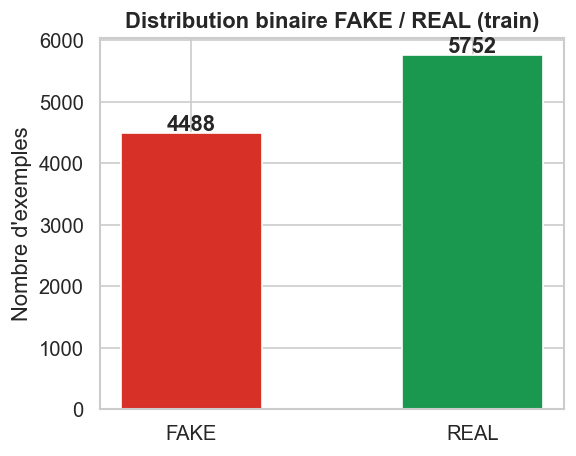

In [9]:
# ── Mappage binaire : FAKE vs REAL ────────────────────────────────────────────
# Stratégie recommandée pour la baseline :
#   FAKE = pants-fire, false, barely-true  (affirmations fausses ou très peu vraies)
#   REAL = half-true, mostly-true, true    (affirmations partiellement ou totalement vraies)
#
# NOTE : 'half-true' est placé dans REAL car c'est le "milieu" — on peut aussi
# l'exclure pour avoir des frontières plus nettes (sujet de discussion dans le rapport)

label_binary_map = {
    "pants-fire" : 0,  # FAKE
    "false"      : 0,  # FAKE
    "barely-true": 0,  # FAKE
    "half-true"  : 1,  # REAL (choix discutable — à discuter dans le rapport)
    "mostly-true": 1,  # REAL
    "true"       : 1,  # REAL
}

for split_df in [train, valid, test, df]:
    split_df["label_bin"] = split_df["label"].map(label_binary_map)
    split_df["label_bin_name"] = split_df["label_bin"].map({0: "FAKE", 1: "REAL"})

# Vérification du nouveau déséquilibre
print("Distribution binaire (train) :")
bin_counts = train["label_bin_name"].value_counts()
for lbl, cnt in bin_counts.items():
    print(f"  {lbl} : {cnt:5d} ({cnt/len(train)*100:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["FAKE", "REAL"], [bin_counts.get("FAKE", 0), bin_counts.get("REAL", 0)],
       color=["#d73027", "#1a9850"], edgecolor='white', width=0.5)
ax.set_title("Distribution binaire FAKE / REAL (train)", fontweight='bold')
ax.set_ylabel("Nombre d'exemples")
for i, (lbl, cnt) in enumerate([("FAKE", bin_counts.get("FAKE",0)), ("REAL", bin_counts.get("REAL",0))]):
    ax.text(i, cnt + 50, str(cnt), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("plot_03_binary_distribution.png", bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Analyse des métadonnées — Speaker (locuteur)

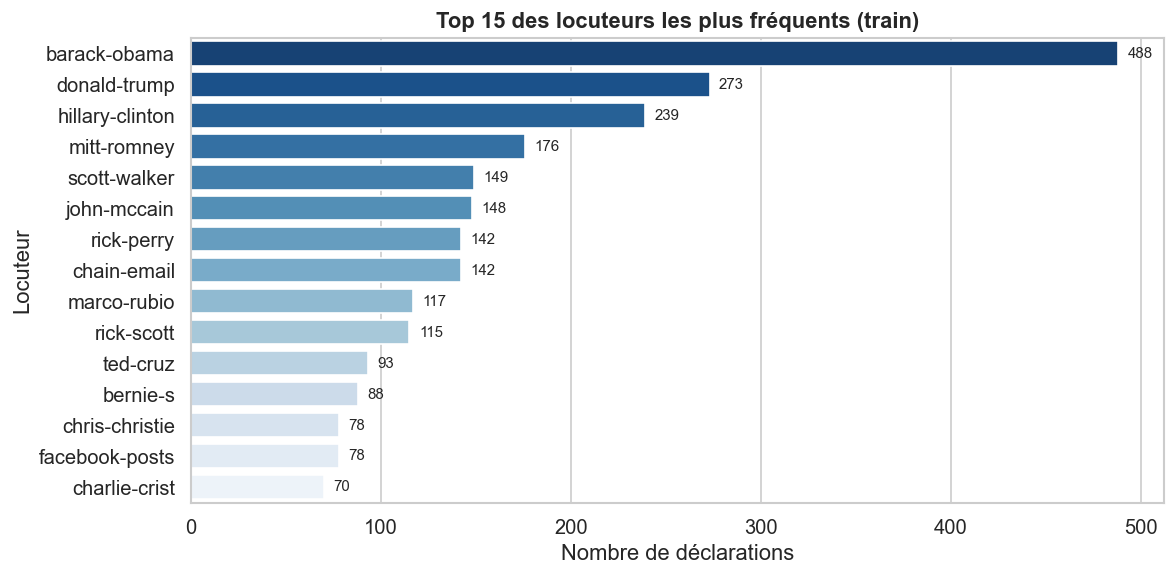


→ Les 15 locuteurs les plus fréquents représentent ~50% du train set
  Nombre total de locuteurs uniques : 2910

→ BIAIS POTENTIEL : Un modèle entraîné sur ce dataset peut apprendre à
  reconnaître les locuteurs habitués à mentir (Trump, etc.) plutôt que
  les caractéristiques linguistiques du mensonge.


In [10]:
# ── Top 15 des locuteurs les plus présents ────────────────────────────────────
# IMPORTANT : si certains locuteurs sont sur-représentés, le modèle risque
# d'apprendre l'identité du locuteur plutôt que le contenu du texte
# → c'est un biais majeur à discuter dans le rapport

top_speakers = train["speaker"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_speakers.values, y=top_speakers.index, palette="Blues_r", ax=ax)
ax.set_title("Top 15 des locuteurs les plus fréquents (train)", fontweight='bold')
ax.set_xlabel("Nombre de déclarations")
ax.set_ylabel("Locuteur")
# Afficher la valeur à la fin de chaque barre
for i, val in enumerate(top_speakers.values):
    ax.text(val + 5, i, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig("plot_04_top_speakers.png", bbox_inches='tight', dpi=150)
plt.show()

# Concentration : combien de locuteurs représentent 50% des données ?
cumsum = top_speakers.cumsum()
threshold_50 = (cumsum <= len(train) * 0.5).sum()
print(f"\n→ Les {threshold_50} locuteurs les plus fréquents représentent ~50% du train set")
print(f"  Nombre total de locuteurs uniques : {train['speaker'].nunique()}")
print("\n→ BIAIS POTENTIEL : Un modèle entraîné sur ce dataset peut apprendre à")
print("  reconnaître les locuteurs habitués à mentir (Trump, etc.) plutôt que")
print("  les caractéristiques linguistiques du mensonge.")

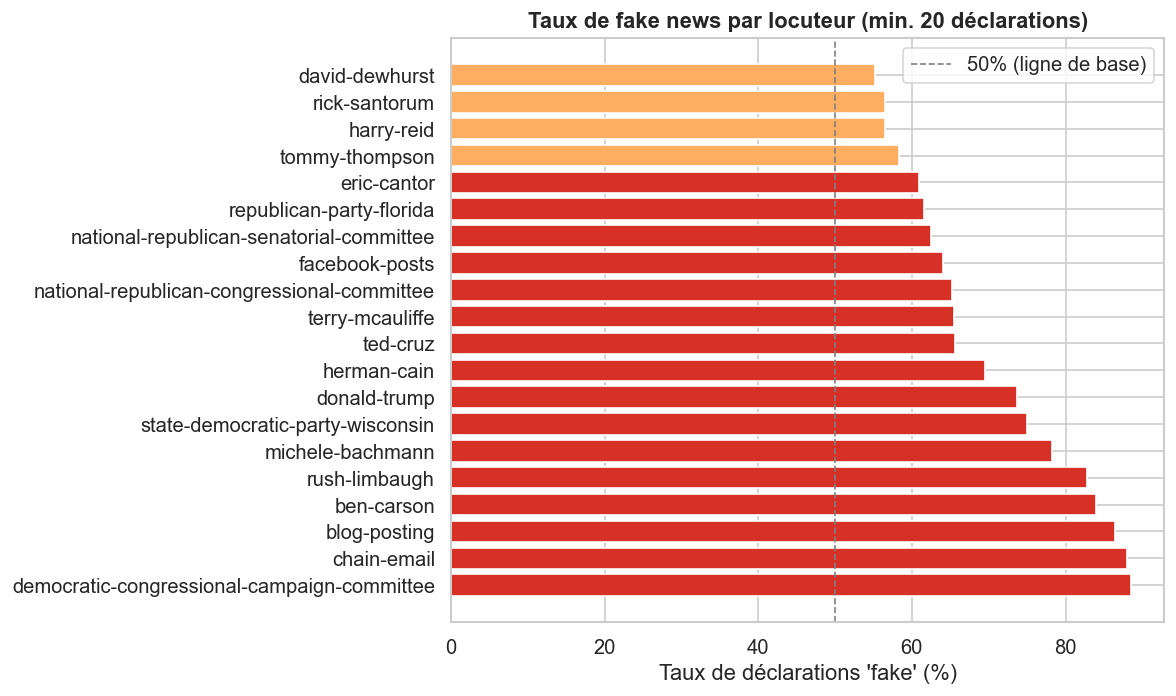

In [11]:
# ── Taux de fake news par locuteur (top 20) ───────────────────────────────────
# Pour chaque locuteur ayant au moins 20 déclarations, calculer son taux de labels 'fake'

# On considère 'fake' = pants-fire + false + barely-true
fake_labels = {"pants-fire", "false", "barely-true"}

speaker_stats = (
    train.groupby("speaker")
    .agg(
        total=("label", "count"),
        fake_count=("label", lambda x: (x.isin(fake_labels)).sum())
    )
    .assign(fake_rate=lambda d: d["fake_count"] / d["total"] * 100)
    .query("total >= 20")           # garder uniquement les locuteurs significatifs
    .sort_values("fake_rate", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
# Colorer en rouge les locuteurs > 60% fake, orange entre 40-60%, vert sinon
colors_spk = ["#d73027" if r > 60 else ("#fdae61" if r > 40 else "#1a9850")
              for r in speaker_stats["fake_rate"]]
ax.barh(speaker_stats.index, speaker_stats["fake_rate"], color=colors_spk)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='50% (ligne de base)')
ax.set_xlabel("Taux de déclarations 'fake' (%)")
ax.set_title("Taux de fake news par locuteur (min. 20 déclarations)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("plot_05_fake_rate_by_speaker.png", bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Analyse des métadonnées — Parti politique

Partis politiques uniques (top 10) :
party_affiliation
republican      4497
democrat        3336
none            1744
organization     219
independent      147
newsmaker         56
libertarian       40
activist          39
journalist        38
columnist         35
Name: count, dtype: int64


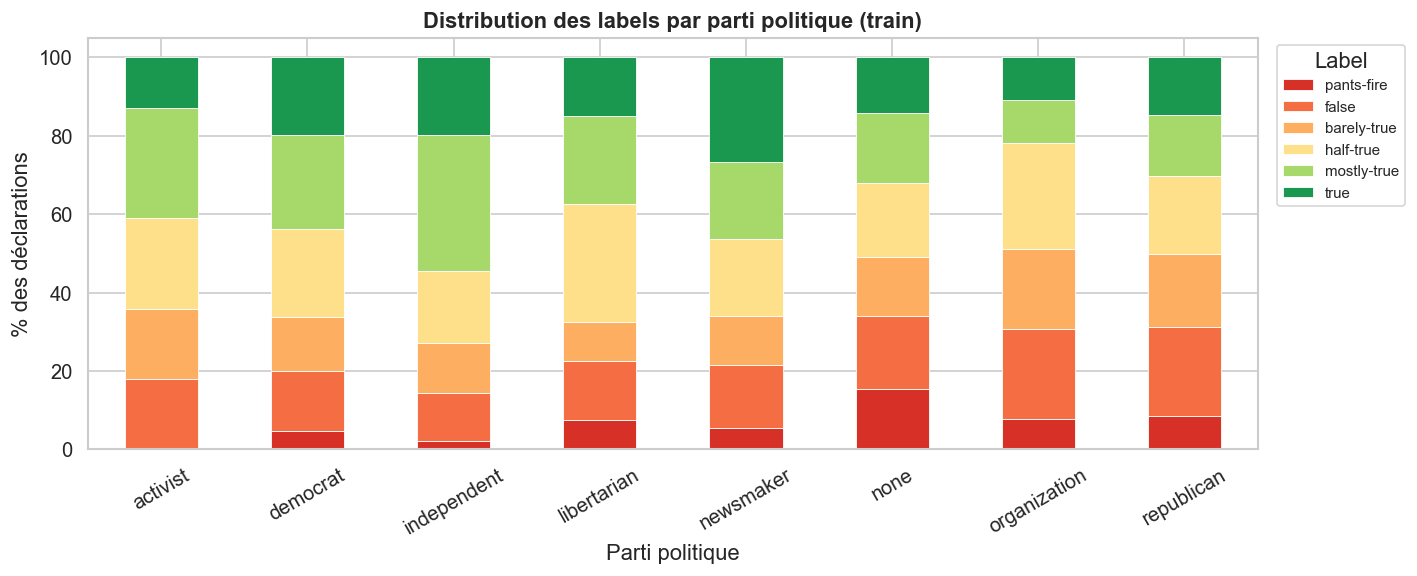


→ OBSERVATION : Certains partis peuvent paraître plus 'honnêtes' que d'autres
  dans ce dataset — mais attention, cela reflète aussi le biais des sources
  (PolitiFact, media américain) et non nécessairement la réalité.


In [12]:
# ── Distribution par parti politique ─────────────────────────────────────────

print("Partis politiques uniques (top 10) :")
print(train["party_affiliation"].value_counts().head(10))

# On garde les partis principaux pour la visualisation
top_parties = train["party_affiliation"].value_counts().head(8).index.tolist()
df_parties  = train[train["party_affiliation"].isin(top_parties)]

# ── Proportion de chaque label par parti ──────────────────────────────────────
party_label = (
    df_parties
    .groupby(["party_affiliation", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)
# Normaliser par ligne pour obtenir des proportions
party_label_pct = party_label.div(party_label.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
party_label_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=colors, edgecolor='white', linewidth=0.5
)
ax.set_title("Distribution des labels par parti politique (train)", fontweight='bold')
ax.set_xlabel("Parti politique")
ax.set_ylabel("% des déclarations")
ax.tick_params(axis='x', rotation=30)
ax.legend(title="Label", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("plot_06_labels_by_party.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ OBSERVATION : Certains partis peuvent paraître plus 'honnêtes' que d'autres")
print("  dans ce dataset — mais attention, cela reflète aussi le biais des sources")
print("  (PolitiFact, media américain) et non nécessairement la réalité.")

In [13]:
# ── Heatmap : taux de 'pants-fire' par parti ──────────────────────────────────
# Le label 'pants-fire' est le mensonge le plus flagrant — intéressant à analyser

fake_by_party = (
    df_parties
    .assign(is_pants_fire=lambda d: (d["label"] == "pants-fire").astype(int))
    .groupby("party_affiliation")["is_pants_fire"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"] * 100)
    .sort_values("rate", ascending=False)
)

print("Taux de 'pants-fire' par parti (%) :")
print(fake_by_party[["sum", "count", "rate"]].rename(
    columns={"sum": "nb_pants_fire", "count": "total", "rate": "taux_%"}
).round(1))

Taux de 'pants-fire' par parti (%) :
                   nb_pants_fire  total  taux_%
party_affiliation                              
none                         269   1744    15.4
republican                   380   4497     8.5
organization                  17    219     7.8
libertarian                    3     40     7.5
newsmaker                      3     56     5.4
democrat                     153   3336     4.6
independent                    3    147     2.0
activist                       0     39     0.0


---
## 6. Analyse des métadonnées — Sujets politiques

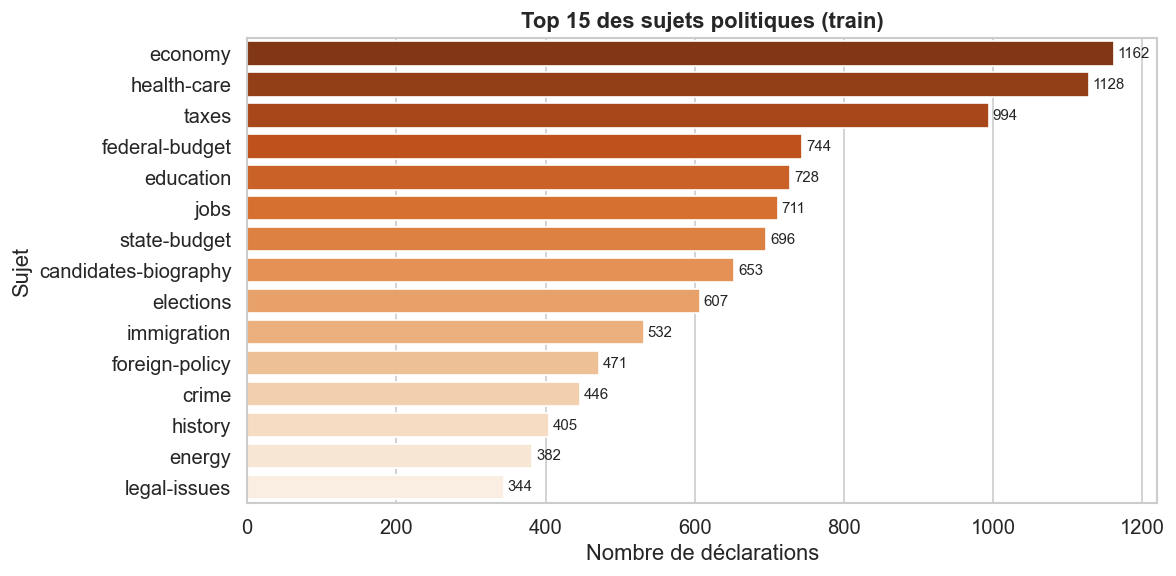


→ OBSERVATION : L'économie, la santé et les taxes sont les sujets dominants.
  Cela correspond bien au contexte de la politique américaine (2007-2017).


In [14]:
# ── Préparation : un statement peut avoir plusieurs sujets (séparés par des virgules) ──
# On les explose pour avoir un sujet par ligne

subjects_exploded = (
    train["subject"].dropna()
    .str.split(",")          # séparer par virgule
    .explode()               # une ligne par sujet
    .str.strip()             # supprimer les espaces
    .str.lower()             # normaliser
)

top_subjects = subjects_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_subjects.values, y=top_subjects.index, palette="Oranges_r", ax=ax)
ax.set_title("Top 15 des sujets politiques (train)", fontweight='bold')
ax.set_xlabel("Nombre de déclarations")
ax.set_ylabel("Sujet")
for i, val in enumerate(top_subjects.values):
    ax.text(val + 5, i, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig("plot_07_top_subjects.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ OBSERVATION : L'économie, la santé et les taxes sont les sujets dominants.")
print("  Cela correspond bien au contexte de la politique américaine (2007-2017).")

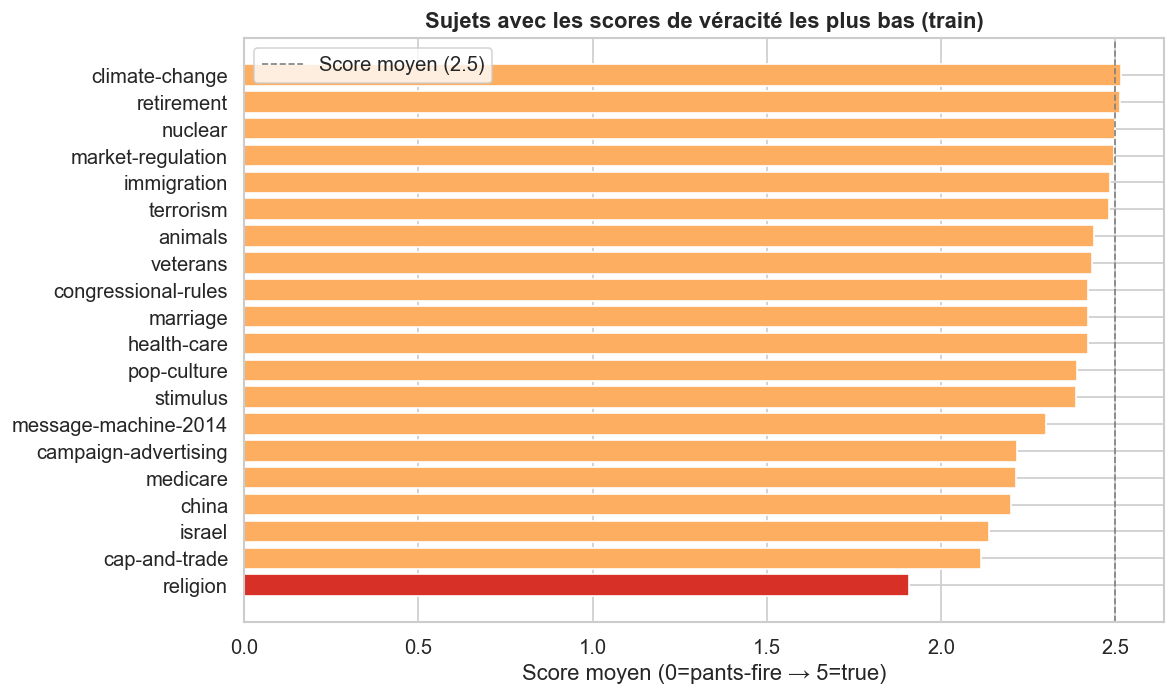

In [15]:
# ── Label moyen par sujet (quel sujet génère le plus de fake news ?) ───────────

# On attribue un score numérique au label (0=pants-fire, 5=true)
label_score_map = {
    "pants-fire" : 0,
    "false"      : 1,
    "barely-true": 2,
    "half-true"  : 3,
    "mostly-true": 4,
    "true"       : 5
}
train["label_score"] = train["label"].map(label_score_map)

# Score moyen par sujet : bas = beaucoup de mensonges, haut = beaucoup de vérités
subject_score = (
    train.assign(subject_split=train["subject"].str.split(","))
    .explode("subject_split")
    .assign(subject_split=lambda d: d["subject_split"].str.strip().str.lower())
    .groupby("subject_split")["label_score"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean")
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_subj = ["#d73027" if s < 2 else ("#fdae61" if s < 3 else "#1a9850")
               for s in subject_score["mean"]]
ax.barh(subject_score.index, subject_score["mean"], color=colors_subj)
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=1, label='Score moyen (2.5)')
ax.set_xlabel("Score moyen (0=pants-fire → 5=true)")
ax.set_title("Sujets avec les scores de véracité les plus bas (train)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("plot_08_veracity_by_subject.png", bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Analyse du texte — longueur des statements

Statistiques sur la longueur des statements (en mots) :
count    10240.0
mean        18.0
std          9.7
min          2.0
25%         12.0
50%         17.0
75%         22.0
max        467.0
Name: statement_len, dtype: float64


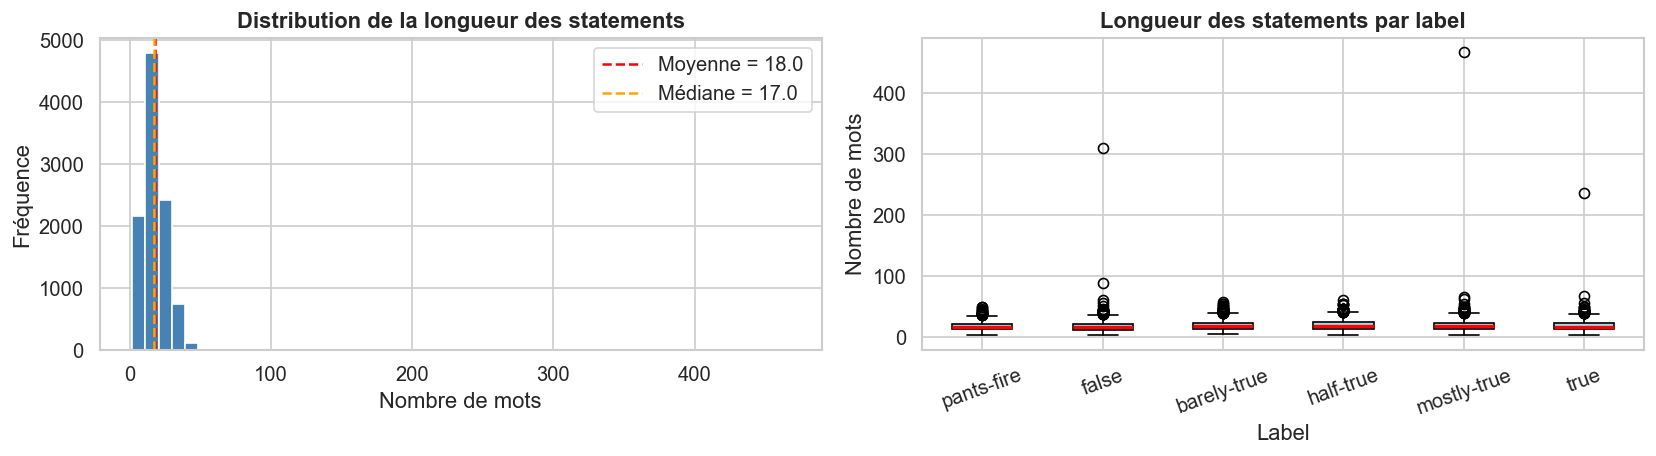


→ OBSERVATION : Les statements sont courts (~17 mots en médiane).
  Peu de différence de longueur entre les labels → la longueur n'est pas
  un signal prédictif fort. Le contenu sémantique est crucial.


In [16]:
# ── Longueur des statements en nombre de mots ─────────────────────────────────
# Rappel : LIAR contient des déclarations très courtes (avg ~17 mots)
# C'est un défi pour le NLP car peu de contexte disponible

train["statement_len"] = train["statement"].apply(lambda x: len(str(x).split()))

print("Statistiques sur la longueur des statements (en mots) :")
print(train["statement_len"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution globale
axes[0].hist(train["statement_len"], bins=50, color="steelblue", edgecolor='white')
axes[0].axvline(train["statement_len"].mean(), color='red', linestyle='--',
                label=f"Moyenne = {train['statement_len'].mean():.1f}")
axes[0].axvline(train["statement_len"].median(), color='orange', linestyle='--',
                label=f"Médiane = {train['statement_len'].median():.1f}")
axes[0].set_title("Distribution de la longueur des statements", fontweight='bold')
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Longueur par label
len_by_label = [train[train["label"] == lbl]["statement_len"].values for lbl in label_order]
axes[1].boxplot(len_by_label, labels=label_order, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Longueur des statements par label", fontweight='bold')
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Nombre de mots")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("plot_09_statement_length.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ OBSERVATION : Les statements sont courts (~17 mots en médiane).")
print("  Peu de différence de longueur entre les labels → la longueur n'est pas")
print("  un signal prédictif fort. Le contenu sémantique est crucial.")

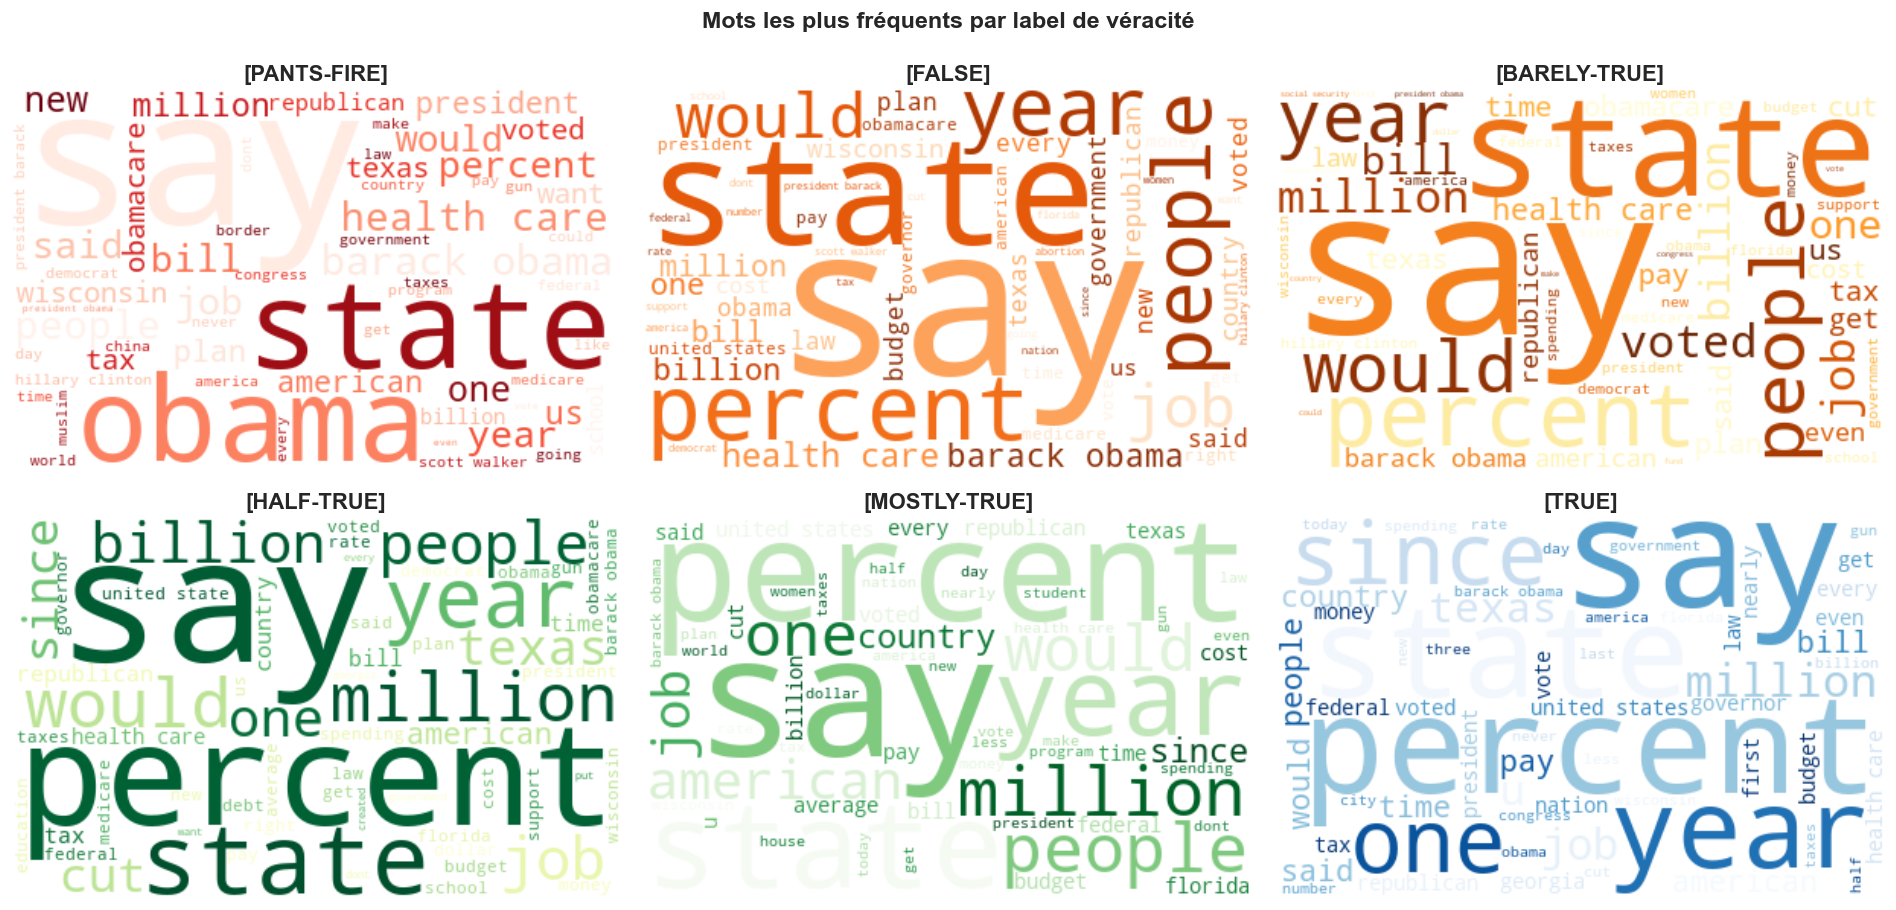

In [17]:
# ── Nuage de mots par classe (si WordCloud disponible) ────────────────────────

if WORDCLOUD_AVAILABLE:
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    wc_colors = ["Reds", "Oranges", "YlOrBr", "YlGn", "Greens", "Blues"]

    for ax, lbl, cmap in zip(axes, label_order, wc_colors):
        # Récupérer tous les statements du label
        texts = " ".join(train[train["label"] == lbl]["statement"].dropna().tolist())
        # Nettoyer
        texts = re.sub(r"[^a-zA-Z\s]", "", texts.lower())

        wc = WordCloud(
            width=400, height=250,
            background_color='white',
            stopwords=stop_words,
            colormap=cmap,
            max_words=60
        ).generate(texts)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"[{lbl.upper()}]", fontweight='bold')
        ax.axis('off')

    plt.suptitle("Mots les plus fréquents par label de véracité", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("plot_10_wordclouds.png", bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("WordCloud non disponible — installer avec : pip install wordcloud")

---
## 8. Analyse des credit history counts

Les colonnes 8–12 donnent l'historique des labels du locuteur (combien de fois il a été étiqueté 'false', 'half-true', etc. dans le passé). C'est une **feature très puissante** mais qui introduit un **biais de speaker**.

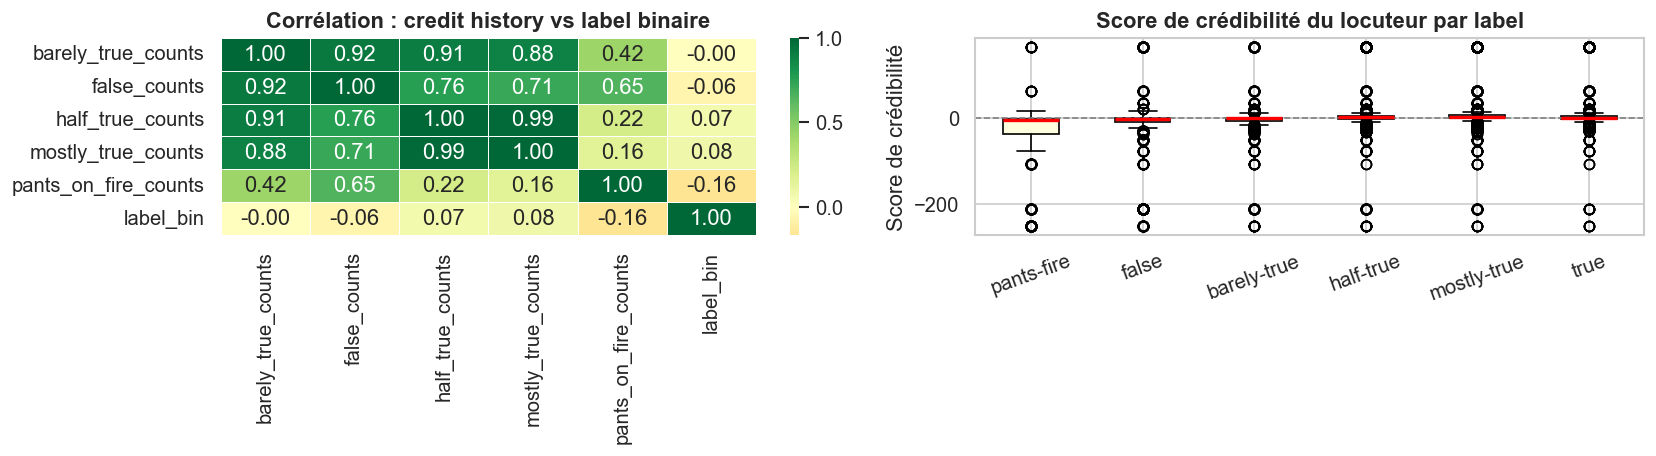


→ OBSERVATION : Le score de crédibilité est positivement corrélé avec le label.
  Les locuteurs 'pants-fire' ont un historique très négatif.
  MAIS utiliser ces features = classifier le locuteur, pas le texte.
  Ce n'est pas transférable sur un dataset externe (BuzzFeed, FakeNewsNet)
  qui n'a pas d'historique PolitiFact.


In [18]:
# ── Corrélation entre credit history et label binaire ─────────────────────────

count_cols = ["barely_true_counts", "false_counts", "half_true_counts",
              "mostly_true_counts", "pants_on_fire_counts"]

# Convertir en numérique (peut contenir des NaN)
for col in count_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0)

# Score de "crédibilité" global du locuteur
# Idée : somme des faux labels pondérée négativement, vrais labels positivement
train["credibility_score"] = (
    train["mostly_true_counts"] + train["half_true_counts"]
    - train["false_counts"] - train["barely_true_counts"]
    - 2 * train["pants_on_fire_counts"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Matrice de corrélation entre les counts et le label binaire
corr_data = train[count_cols + ["label_bin"]].corr()
sns.heatmap(
    corr_data, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, ax=axes[0], linewidths=0.5
)
axes[0].set_title("Corrélation : credit history vs label binaire", fontweight='bold')

# Credibility score par label
cred_by_label = [train[train["label"] == lbl]["credibility_score"].values
                 for lbl in label_order]
axes[1].boxplot(cred_by_label, labels=label_order, patch_artist=True,
                boxprops=dict(facecolor='lightyellow'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Score de crédibilité du locuteur par label", fontweight='bold')
axes[1].set_ylabel("Score de crédibilité")
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig("plot_11_credit_history.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ OBSERVATION : Le score de crédibilité est positivement corrélé avec le label.")
print("  Les locuteurs 'pants-fire' ont un historique très négatif.")
print("  MAIS utiliser ces features = classifier le locuteur, pas le texte.")
print("  Ce n'est pas transférable sur un dataset externe (BuzzFeed, FakeNewsNet)")
print("  qui n'a pas d'historique PolitiFact.")

---
## 9. Choix du dataset externe pour l'évaluation out-of-domain

Deux candidats :
- **FakeNewsNet** — articles de presse avec labels fake/real (GossipCop + PolitiFact)
- **BuzzFeed Political Dataset** — posts Facebook de la campagne 2016 avec fact-check

**Notre choix : BuzzFeed Political Dataset**

Raisons :
1. Format similaire à LIAR (déclarations courtes, contexte politique américain)
2. Labels binaires clairs (mostly true / mixture of true and false / mostly false / no factual content)
3. Plus facile à mapper sur la classification binaire FAKE/REAL
4. FakeNewsNet contient des articles longs → domain shift très fort (bonne ou mauvaise chose selon l'objectif)

In [19]:
# ── Téléchargement du BuzzFeed Political Dataset ──────────────────────────────

BUZZFEED_URL = (
    "https://raw.githubusercontent.com/BuzzFeedNews/"
    "2016-10-facebook-fact-check/master/data/facebook-fact-check.csv"
)

if not os.path.exists("data/buzzfeed.csv"):
    print("Téléchargement du BuzzFeed dataset...")
    os.system(f"wget -q {BUZZFEED_URL} -O data/buzzfeed.csv")
    print("  ✓ buzzfeed.csv sauvegardé")
else:
    print("  ✓ buzzfeed.csv déjà présent")

buzz = pd.read_csv("data/buzzfeed.csv")
print(f"\nShape : {buzz.shape}")
print("\nColonnes disponibles :")
print(buzz.columns.tolist())
print("\nAperçu :")
buzz.head(3)

Téléchargement du BuzzFeed dataset...
  ✓ buzzfeed.csv sauvegardé


FileNotFoundError: [Errno 2] No such file or directory: 'data/buzzfeed.csv'

In [ ]:
# ── Exploration du BuzzFeed dataset ───────────────────────────────────────────

print("Distribution des labels BuzzFeed :")
print(buzz["Rating"].value_counts())

# ── Mappage des labels BuzzFeed → binaire compatible avec LIAR ─────────────────
# BuzzFeed labels :
#   'mostly true'              → REAL (1)
#   'mixture of true and false'→ REAL (1) — choix discutable, voir rapport
#   'mostly false'             → FAKE (0)
#   'no factual content'       → exclure (ni vrai ni faux)

buzzfeed_label_map = {
    "mostly true"              : 1,   # REAL
    "mixture of true and false": 1,   # REAL (nuancé — à discuter)
    "mostly false"             : 0,   # FAKE
    "no factual content"       : None # à exclure
}

buzz["label_bin"]  = buzz["Rating"].str.lower().str.strip().map(buzzfeed_label_map)
buzz["statement"]  = buzz["Title"]   # utiliser le titre comme texte (similaire à LIAR)

# Exclure les lignes sans label valide
buzz_clean = buzz.dropna(subset=["label_bin", "statement"]).copy()
buzz_clean["label_bin"] = buzz_clean["label_bin"].astype(int)

print(f"\nBuzzFeed après nettoyage : {len(buzz_clean)} exemples")
print("Distribution binaire :")
print(buzz_clean["label_bin"].map({0: "FAKE", 1: "REAL"}).value_counts())

In [ ]:
# ── Comparaison LIAR vs BuzzFeed : longueur des textes ────────────────────────
# Une différence de longueur significative = domain shift important

buzz_clean["text_len"] = buzz_clean["statement"].apply(lambda x: len(str(x).split()))
train["text_len"]      = train["statement"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train["text_len"], bins=40, alpha=0.6, color="steelblue",
        label=f"LIAR (moy={train['text_len'].mean():.1f} mots)", density=True)
ax.hist(buzz_clean["text_len"], bins=40, alpha=0.6, color="coral",
        label=f"BuzzFeed (moy={buzz_clean['text_len'].mean():.1f} mots)", density=True)
ax.set_title("Comparaison de la longueur des textes — LIAR vs BuzzFeed", fontweight='bold')
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.savefig("plot_12_liar_vs_buzzfeed_length.png", bbox_inches='tight', dpi=150)
plt.show()

print("\n→ DOMAIN SHIFT : Si les longueurs sont très différentes, le modèle entraîné")
print("  sur LIAR (phrases courtes) peut mal se généraliser sur BuzzFeed (titres d'articles).")

---
## 10. Récapitulatif EDA — Résumé des observations clés

In [ ]:
# ── Tableau récapitulatif des statistiques clés ────────────────────────────────

print("=" * 65)
print("RÉCAPITULATIF EDA — LIAR DATASET")
print("=" * 65)

print(f"\n1. TAILLE")
print(f"   Train : {len(train):,} | Valid : {len(valid):,} | Test : {len(test):,}")

print(f"\n2. LABELS")
for lbl in label_order:
    cnt = train[train['label'] == lbl].shape[0]
    print(f"   {lbl:15s}: {cnt:5d} ({cnt/len(train)*100:.1f}%)")

print(f"\n3. TEXTE")
print(f"   Longueur moyenne  : {train['statement_len'].mean():.1f} mots")
print(f"   Longueur médiane  : {train['statement_len'].median():.0f} mots")
print(f"   Longueur max      : {train['statement_len'].max()} mots")

print(f"\n4. MÉTADONNÉES")
print(f"   Locuteurs uniques : {train['speaker'].nunique()}")
print(f"   Partis uniques    : {train['party_affiliation'].nunique()}")
print(f"   Sujets uniques    : {train['subject'].nunique()}")
print(f"   Contextes uniques : {train['context'].nunique()}")

print(f"\n5. VALEURS MANQUANTES (train)")
missing = train.isnull().sum()
for col, n in missing[missing > 0].items():
    print(f"   {col:25s}: {n} ({n/len(train)*100:.1f}%)")
if missing.sum() == 0:
    print("   Aucune valeur manquante")

print(f"\n6. DATASET EXTERNE")
print(f"   BuzzFeed Political Dataset : {len(buzz_clean):,} exemples")
print(f"   Labels : {buzz_clean['label_bin'].map({0:'FAKE',1:'REAL'}).value_counts().to_dict()}")

print("\n" + "=" * 65)
print("POINTS CLÉS POUR LE RAPPORT")
print("=" * 65)
print("""
  ① Déséquilibre modéré : pants-fire sous-représenté (~8%)
     → Utiliser class_weight='balanced' ou regroupement binaire

  ② Biais de speaker : quelques locuteurs très dominants
     → Le modèle peut apprendre l'identité plutôt que le texte
     → Tester les performances en masquant le speaker

  ③ Textes courts (~17 mots) : TF-IDF limité, BERT recommandé
     → Peu de contexte = difficulté pour les modèles simples

  ④ Domain shift LIAR → BuzzFeed :
     → Différences de style (déclarations vs titres d'articles)
     → Vocabulaire et contexte temporel différents
     → Anticiper une baisse de performance out-of-domain
""")

In [ ]:
# ── Sauvegarde des données préparées pour les notebooks suivants ───────────────
# On sauvegarde les datasets nettoyés avec les colonnes utiles

COLS_SAVE = ["id", "label", "label_bin", "statement", "speaker",
             "party_affiliation", "subject", "context",
             "barely_true_counts", "false_counts", "half_true_counts",
             "mostly_true_counts", "pants_on_fire_counts", "split"]

# Filtrer les colonnes disponibles
cols_available = [c for c in COLS_SAVE if c in df.columns]

train[cols_available].to_csv("data/train_clean.csv", index=False)
valid[cols_available].to_csv("data/valid_clean.csv",  index=False)
test[cols_available].to_csv("data/test_clean.csv",   index=False)

buzz_clean[["statement", "label_bin", "Rating"]].to_csv("data/buzzfeed_clean.csv", index=False)

print("✓ Fichiers sauvegardés :")
print("  data/train_clean.csv")
print("  data/valid_clean.csv")
print("  data/test_clean.csv")
print("  data/buzzfeed_clean.csv")
print("\n→ Ces fichiers seront utilisés dans le notebook 02 (Prétraitement & Modélisation)")